# Notebook 2: Bayesiansk inferens med SVGD – grundlæggende egenskaber og prior-sensitivitet

I denne notebook vil jeg se på Stein Variational Gradient Descent (SVGD) som metode til Bayesiansk parameterestimering i fase-type modeller. Jeg starter med en single-parameter coalescent og undersøger, hvordan valget af prior, læringsrate og regularisering påvirker konvergens og posterior-præcision. Jeg undersøger desuden prøvestørrelse-effekter og posterior-bredde.

**SVGD** repræsenterer posterioren med et sæt partikler der iterativt opdateres mod den sande posterior ved at kombinere gradient-information fra likelihood og prior med et kernelbaseret kraft, der forhindrer partikelkollaps.

**Kalibrering (ingen peaks).**: en informativ men ikke for smal prior (GaussPrior/ HalfCauchyPrior/DataPrior) kombineret med en aftagende læringsrate (ExpStepSize) eller en adaptiv optimizer (Adam). Målet er en **bred, flad posterior** der dækker den sande værdi, ikke en spids ("peaked") posterior, som er tegn på numerisk kollaps eller for høj læringsrate. Afsnittet *SVGD posterior-form: peaked vs. flad* viser denne kontrast eksplicit via kurtosis.

In [1]:
# Importer de nødvendige pakker
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"


from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, LogGaussPrior,
    Adam, Adamelia, SGDMomentum, RMSprop, Adagrad,
    ExpStepSize, ExpRegularization, ConstantStepSize,
    WarmupExpStepSize, AdaptiveStepSize, ConstantRegularization,
    StateIndexer, Property,
    clear_caches, set_log_level
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (6, 3)

clear_caches()

  Removed 794 file(s), preserved directory structure


In [4]:
# Standard coalescent som i notebook 01
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
true_theta = [7.0]
graph.update_weights(true_theta)

## 1. Læringsrate-strategier

Phasic tilbyder `ConstantStepSize`, `ExpStepSize`, `WarmupExpStepSize` og `AdaptiveStepSize`. Jeg tester disse systematisk over et bredt interval af start-rater ($0.001$–$1.0$) og iterationer ($100$–$1000$) for at finde den bedste kombination.

Alle tests i denne blok bruger: $n_{\text{obs}}=3000$, $n_{\text{particles}}=20$, `DataPrior`, sand $\theta=7$.

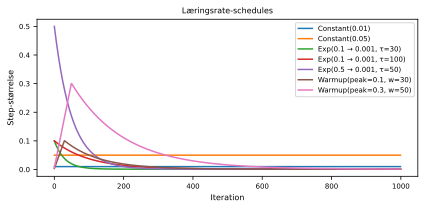

In [ ]:
#| label: fig-lr-schedules
#| fig-cap: 'Syv læringsrate-strategier over $1000$ iterationer. x-aksen viser iteration og y-aksen step-størrelse. Constant(0.01) (blå) og Constant(0.05) (orange) er flade. Exp(0.1 → 0.001, τ=30) (grøn), Exp(0.1 → 0.001, τ=100) (rød) og Exp(0.5 → 0.001, τ=50) (lilla) falder eksponentielt fra start. Warmup(peak=0.1, w=30) (brun) og Warmup(peak=0.3, w=50) (pink) stiger først til et peak og falder derefter.'
#| fig-width: 5
#| fig-height: 3.5

N_ITER_VIS = 1000
iters_vis = np.arange(N_ITER_VIS)
fig, ax = plt.subplots(figsize=(6, 3))
schedules_vis = {
    f'Constant(0.01)':              ConstantStepSize(0.01),
    f'Constant(0.05)':              ConstantStepSize(0.05),
    f'Exp(0.1 → 0.001, τ=30)':  ExpStepSize(0.1,  0.001, 30.0),
    f'Exp(0.1 → 0.001, τ=100)': ExpStepSize(0.1,  0.001, 100.0),
    f'Exp(0.5 → 0.001, τ=50)':  ExpStepSize(0.5,  0.001, 50.0),
    f'Warmup(peak=0.1, w=30)':    WarmupExpStepSize(0.1, 30, 0.001, 100.0),
    f'Warmup(peak=0.3, w=50)':    WarmupExpStepSize(0.3, 50, 0.001, 150.0),
}
for name, sched in schedules_vis.items():
    vals = [float(sched(i)) for i in iters_vis]
    ax.plot(iters_vis, vals, label=name)
ax.set_xlabel('Iteration', fontsize=8)
ax.set_ylabel('Step-størrelse', fontsize=8)
ax.set_title('Læringsrate-schedules', fontsize=8)
ax.legend(fontsize=7)
ax.tick_params(labelsize=7)
plt.tight_layout(); plt.show()

In [53]:
import time

graph.update_weights(true_theta)
data_lr = graph.sample(10000)
prior_lr = DataPrior(graph, data_lr)

lr_configs = {
    f'Constant(0.001)':           {'learning_rate': ConstantStepSize(0.001)},
    f'Constant(0.01)':            {'learning_rate': ConstantStepSize(0.01)},
    f'Constant(0.05)':            {'learning_rate': ConstantStepSize(0.05)},
    f'Constant(0.1)':             {'learning_rate': ConstantStepSize(0.1)},
    f'Constant(0.5)':             {'learning_rate': ConstantStepSize(0.5)},
    f'Exp(0.05 → 0.001, τ=30)':  {'learning_rate': ExpStepSize(0.05, 0.001, 30.0)},
    f'Exp(0.1 → 0.001, τ=30)':   {'learning_rate': ExpStepSize(0.1,  0.001, 30.0)},
    f'Exp(0.1 → 0.001, τ=100)':  {'learning_rate': ExpStepSize(0.1,  0.001, 100.0)},
    f'Exp(0.3 → 0.001, τ=50)':   {'learning_rate': ExpStepSize(0.3,  0.001, 50.0)},
    f'Exp(0.5 → 0.001, τ=50)':   {'learning_rate': ExpStepSize(0.5,  0.001, 50.0)},
    f'Exp(1.0 → 0.01, τ=50)':    {'learning_rate': ExpStepSize(1.0,  0.01,  50.0)},
    f'Warmup(peak=0.1, w=20)':   {'learning_rate': WarmupExpStepSize(0.1, 20, 0.001,  80.0)},
    f'Warmup(peak=0.3, w=30)':   {'learning_rate': WarmupExpStepSize(0.3, 30, 0.001, 100.0)},
    f'Warmup(peak=0.3, w=50)':   {'learning_rate': WarmupExpStepSize(0.3, 50, 0.001, 150.0)},
    f'Warmup(peak=0.5, w=30)':   {'learning_rate': WarmupExpStepSize(0.5, 30, 0.001, 100.0)},
    f'AdaptiveStepSize':          {'learning_rate': AdaptiveStepSize()},
}

rows_lr = []
for n_iter in [300, 400, 600, 1000]:
    for name, kwargs in lr_configs.items():
        t0 = time.perf_counter()
        sv = graph.svgd(data_lr, prior=prior_lr,
                        n_particles=20, n_iterations=n_iter, **kwargs)
        tid = time.perf_counter() - t0
        res = sv.get_results()
        m = float(res['theta_mean'].item())
        s = float(res['theta_std'].item())
        ci_lo = m - 1.96 * s
        ci_hi = m + 1.96 * s
        rows_lr.append({
            'n_iter':    n_iter,
            'Strategi':  name,
            'θ̂':         round(m, 4),
            'Std':       round(s, 5),
            'Bias':      round(abs(m - true_theta[0]), 4),
            'CI_lo':     round(ci_lo, 4),
            'CI_hi':     round(ci_hi, 4),
            'Dækker':    ci_lo <= true_theta[0] <= ci_hi,
            'Tid (s)':   round(tid, 2),
        })

df_lr = pd.DataFrame(rows_lr)
df_lr['Score'] = df_lr['Std'] + df_lr['Bias']

df_lr_dækker = df_lr[df_lr['Dækker']]

if len(df_lr_dækker) == 0:
    print('Advarsel: ingen strategi dækker sand θ — bruger alle')
    df_lr_dækker = df_lr
best_lr_row = df_lr_dækker[df_lr_dækker['n_iter'] >= 300].sort_values('Score').iloc[0]
BEST_LR_NAME  = best_lr_row['Strategi']
BEST_LR_KWARGS = lr_configs[BEST_LR_NAME]
BEST_ITER_LR  = int(best_lr_row['n_iter'])

print(f'Bedste lr-strategi: {BEST_LR_NAME} @ {BEST_ITER_LR} iter')
print(f'Std={best_lr_row["Std"]:.5f}  Bias={best_lr_row["Bias"]:.4f}  Dækker={best_lr_row["Dækker"]}')

Bedste lr-strategi: Exp(0.1 → 0.001, τ=100) @ 300 iter
Std=0.02363  Bias=0.0359  Dækker=True


In [ ]:
#| label: tbl-lr-bred
#| tbl-cap: '16 læringsrate-strategier testet over fem iterationsantal $\{100, 300, 400, 600, 1000\}$ med sand $\theta=7$ og $n=10.000$ observationer. Cellerne viser posterior-std. Strategier med $0{,}00000$ dækker ikke sand $\theta$ i $95\%$-intervallet.'

pivot_std = df_lr.pivot_table(
    index='Strategi', columns='n_iter', values='Std', aggfunc='mean'
).round(5)
print('Std som funktion af strategi og iterationer:')
display(pivot_std)


Std som funktion af strategi og iterationer:


n_iter,100,300,400,600,1000
Strategi,,,,,
AdaptiveStepSize,3.50322,3.50559,13.10750,11.98529,8.52756
Constant(0.001),0.06508,0.04038,0.02779,0.03789,0.07295
Constant(0.01),0.02153,0.01217,0.05662,0.01822,0.02644
Constant(0.05),0.05499,0.02491,0.01534,0.01508,0.04527
Constant(0.1),20.82313,25.33872,27.62536,7.25658,1.19354
Constant(0.5),0.00000,0.00000,0.00000,0.00000,0.00000
"Exp(0.05 → 0.001, τ=30)",0.03718,0.03236,0.12737,0.04072,0.17019
"Exp(0.1 → 0.001, τ=100)",0.00553,0.02363,0.12584,0.02851,0.11037
"Exp(0.1 → 0.001, τ=30)",0.01983,0.16619,0.01761,0.09809,0.07473


In [55]:
pivot_dækker = df_lr.pivot_table(
    index='Strategi', columns='n_iter', values='Dækker', aggfunc='mean'
).round(2)
print('\nAndel iterationer hvor CI dækker sand θ:')
display(pivot_dækker)


Andel iterationer hvor CI dækker sand θ:


n_iter,100,300,400,600,1000
Strategi,,,,,
AdaptiveStepSize,1.0,1.0,1.0,1.0,1.0
Constant(0.001),1.0,1.0,1.0,1.0,1.0
Constant(0.01),1.0,0.0,1.0,0.0,1.0
Constant(0.05),1.0,0.0,0.0,0.0,1.0
Constant(0.1),1.0,1.0,1.0,1.0,1.0
Constant(0.5),0.0,0.0,0.0,0.0,0.0
"Exp(0.05 → 0.001, τ=30)",1.0,1.0,1.0,1.0,1.0
"Exp(0.1 → 0.001, τ=100)",0.0,1.0,1.0,1.0,1.0
"Exp(0.1 → 0.001, τ=30)",1.0,1.0,0.0,1.0,1.0


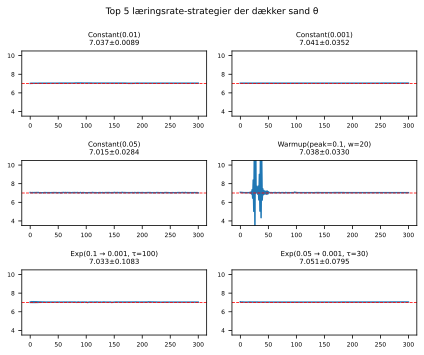

In [ ]:
#| label: fig-lr-top6
#| fig-cap: 'Konvergensplots for de seks bedste læringsrate-strategier der alle dækker sand $\theta=7$. Hvert panel viser posterior-mean (blå linje) over 300 iterationer med $\pm 1$ SD som skravering og titlen angiver strategi samt slutværdi $\pm$ std. Rød stiplet linje markerer sand $\theta=7$.'
#| fig-width: 6
#| fig-height: 5

top6_lr = (df_lr[df_lr['Dækker']]
           .groupby('Strategi')['Score'].mean()
           .sort_values().head(6).index.tolist())

fig, axes = plt.subplots(3, 2, figsize=(6, 5))
for ax, name in zip(axes.flat, top6_lr):
    sv_t = graph.svgd(data_lr, prior=prior_lr,
                      n_particles=20, n_iterations=BEST_ITER_LR,
                      return_history=True, **lr_configs[name])
    res_t = sv_t.get_results()
    m = float(res_t['theta_mean'].item())
    s = float(res_t['theta_std'].item())
    ax.plot(sv_t.history_iterations, [h.mean() for h in sv_t.history])
    ax.axhline(true_theta[0], color='r', linestyle='--', lw=0.8)
    ax.set_ylim(true_theta[0] * 0.5, true_theta[0] * 1.2)    
    ax.set_title(f'{name}\n{m:.3f}±{s:.4f}', fontsize=7)
    ax.tick_params(labelsize=6)
for j in range(len(top6_lr), len(axes.flat)): axes.flat[j].set_visible(False)
plt.suptitle(f'Top 5 læringsrate-strategier der dækker sand θ', fontsize=9)
plt.tight_layout(); 

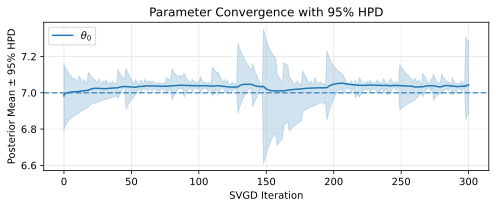

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-lr-ci-1
#| fig-cap: 'Posterior credibility interval (CI) for Constant(0.01) over 300 iterationer med sand $\theta=7$. Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet. Stiplet linje markerer sand $\theta=7$.'


sv_t = graph.svgd(data_lr, prior=prior_lr,
                  n_particles=20, n_iterations=BEST_ITER_LR,
                  **lr_configs[f'Constant(0.01)'])
res_t = sv_t.get_results()
sv_t.plot_ci(true_theta=true_theta)


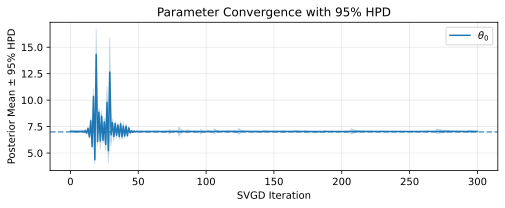

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-lr-ci-2
#| fig-cap: 'Posterior credibility interval (CI) for Exp(0.1 → 0.001, τ=100) over 300 iterationer med sand $\theta=7$. Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet. Stiplet linje markerer sand $\theta=7$.'

sv_t = graph.svgd(data_lr, prior=prior_lr,
                  n_particles=20, n_iterations=BEST_ITER_LR,
                  **lr_configs[f'Exp(0.1 → 0.001, τ=100)'])
res_t = sv_t.get_results()
sv_t.plot_ci(true_theta=true_theta)


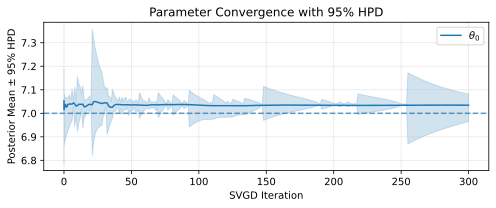

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-lr-ci-3
#| fig-cap: 'Posterior credibility interval (CI) for Exp(0.05 → 0.001, τ=30) over 300 iterationer med sand $\theta=7$. Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet. Stiplet linje markerer sand $\theta=7$.'

sv_t = graph.svgd(data_lr, prior=prior_lr,
                  n_particles=20, n_iterations=BEST_ITER_LR,
                  **lr_configs[f'Exp(0.05 → 0.001, τ=30)'])
res_t = sv_t.get_results()
sv_t.plot_ci(true_theta=true_theta)


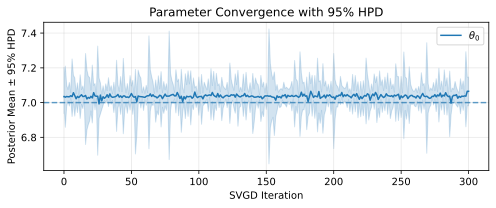

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-lr-ci-4
#| fig-cap: 'Posterior credibility interval (CI) for Constant(0.05) over 300 iterationer med sand $\theta=7$. Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet. Stiplet linje markerer sand $\theta=7$.'

sv_t = graph.svgd(data_lr, prior=prior_lr,
                  n_particles=20, n_iterations=BEST_ITER_LR,
                  **lr_configs[f'Constant(0.05)'])
res_t = sv_t.get_results()
sv_t.plot_ci(true_theta=true_theta)


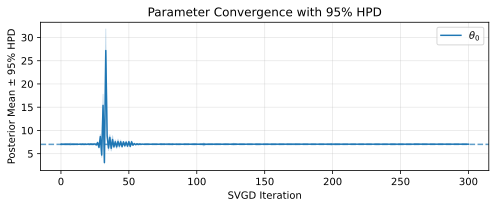

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-lr-ci-5
#| fig-cap: 'Posterior credibility interval (CI) for Warmup (peak=0.1, w=20) over 300 iterationer med sand $\theta=7$. Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet. Stiplet linje markerer sand $\theta=7$.'


sv_t = graph.svgd(data_lr, prior=prior_lr,
                  n_particles=20, n_iterations=BEST_ITER_LR,
                  **lr_configs[f'Warmup(peak=0.1, w=20)'])
res_t = sv_t.get_results()
sv_t.plot_ci(true_theta=true_theta)


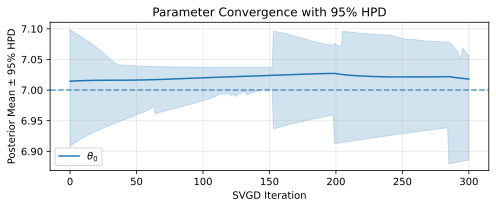

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-lr-ci-6
#| fig-cap: 'Posterior credibility interval (CI) for Constant(0.001) over 300 iterationer med sand $\theta=7$. Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet. Stiplet linje markerer sand $\theta=7$.'

sv_t = graph.svgd(data_lr, prior=prior_lr,
                  n_particles=20, n_iterations=BEST_ITER_LR,
                  **lr_configs[f'Constant(0.001)'])
res_t = sv_t.get_results()
sv_t.plot_ci(true_theta=true_theta)


## 2. Prior-sammenligning

Med den bedste læringsrate (`BEST_LR_KWARGS`) tester jeg seks prior-strategier. Formålet er at finde den prior der giver lavest bias og std uanset startpunkt.

Alle tests: $n_{\text{obs}}=10000$, $n_{\text{particles}}=20$, $n_{\text{iter}}=300$, sand $\theta=7$, `BEST_LR_KWARGS`.

In [69]:
N_OBS = 10000
graph.update_weights(true_theta)
observed_data = graph.sample(N_OBS)

prior_vag        = GaussPrior(mean=5.0, std=10.0)
prior_korrekt    = GaussPrior(ci=[4.0, 10.0])
prior_halfcauchy = HalfCauchyPrior(ci=20.0)
prior_loggauss   = LogGaussPrior(ci=[2.0, 15.0])
prior_datap      = DataPrior(graph, observed_data)

priors_liste = [
    (prior_vag,        'Vag GaussPrior'),
    (prior_korrekt,    'GaussPrior'),
    (prior_halfcauchy, 'HalfCauchyPrior'),
    (prior_loggauss,   'LogGaussPrior'),
    (prior_datap,      'DataPrior'),
]

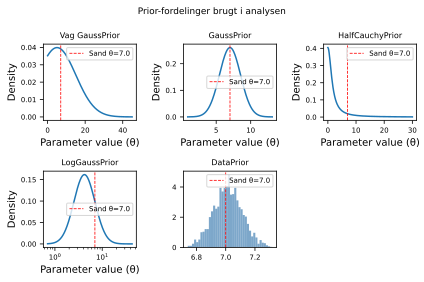

In [ ]:
#| label: fig-priors
#| fig-cap: 'De fem prior-fordelinger testet i analysen. Hvert panel viser sandsynlighedstæthed (y-akse) som funktion af $\theta$ (x-akse) med rød stiplet linje ved sand $\theta=7$. Vag GaussPrior (øverst venstre) og GaussPrior (øverst midten) er vist på lineær skala, HalfCauchyPrior (øverst højre) er vist på lineær skala op til $\theta=30$, LogGaussPrior (nederst venstre) er vist på log-skala, og DataPrior (nederst midten) er vist som histogram.'
#| fig-width: 5
#| fig-height: 3.5

import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(42)

priors_liste = [
    (prior_vag,        'Vag GaussPrior'),
    (prior_korrekt,    'GaussPrior'),
    (prior_halfcauchy, 'HalfCauchyPrior'),
    (prior_loggauss,   'LogGaussPrior'),
    (prior_datap,      'DataPrior'),
]

fig, axes = plt.subplots(2, 3, figsize=(6, 4))

for ax, (prior, title) in zip(axes.flat, priors_liste):
    if isinstance(prior, DataPrior):
        samples = np.array(prior.sample(key, (2000,))).flatten()
        samples = samples[(samples > 0) & (samples < 30)]
        ax.hist(samples, bins=40, density=True, alpha=0.7,
                color='steelblue', edgecolor='none')
    else:
        prior.plot(ax=ax, return_ax=True)
    ax.axvline(true_theta[0], color='red', linestyle='--', linewidth=0.8,
               label=f'Sand θ={true_theta[0]}')
    ax.set_title(title, fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(priors_liste), len(axes.flat)):
    axes.flat[j].set_visible(False)

plt.suptitle('Prior-fordelinger brugt i analysen', fontsize=9)
plt.tight_layout();


In [ ]:
#| label: tbl-prior-sammenligning
#| tbl-cap: 'Sammenligning af fem priors med læringsrate Exp(0.1 → 0.001, τ=100) og sand $\theta=7$. Rækkerne viser posterior-mean $\hat{\theta}$, posterior-std, om sand $\theta$ dækkes i $95\%$-intervallet og samlet score (std $+$ $2 \times$ bias). Kolonnerne svarer til de fem priors.'

svgd_priors = {}
for name, prior in [
        ('Vag GaussPrior',  prior_vag),
        ('GaussPrior',      prior_korrekt),
        ('HalfCauchyPrior', prior_halfcauchy),
        ('LogGaussPrior',   prior_loggauss),
        ('DataPrior',       prior_datap),
    ]:
    sv = graph.svgd(
        observed_data, prior=prior,
        n_particles=20, n_iterations=BEST_ITER_LR,
        return_history=True, **BEST_LR_KWARGS
    )
    res = sv.get_results()
    m = float(res['theta_mean'].item())
    s = float(res['theta_std'].item())
    ci_lo = m - 1.96 * s
    ci_hi = m + 1.96 * s
    svgd_priors[name] = {
        'svgd':    sv,
        'mean':    m,
        'std':     s,
        'dækker':  ci_lo <= true_theta[0] <= ci_hi,
    }
    print(f"{name:<12}: mean={m:.4f}  std={s:.5f}  dækker={ci_lo <= true_theta[0] <= ci_hi}")

df_priors = pd.DataFrame({
    name: {
        'θ̂':      round(v['mean'], 4),
        'Std':    round(v['std'], 5),
        'Dækker': v['dækker'],
        'Score':  round(v['std'] + 2.0 * abs(v['mean'] - true_theta[0]), 5),
    }
    for name, v in svgd_priors.items()
})
display(df_priors)


DataPrior   : mean=7.0289  std=0.03558  dækker=True


,Vag GaussPrior,GaussPrior,HalfCauchyPrior,LogGaussPrior,DataPrior
θ̂,7.0475,7.0454,7.0355,7.0624,7.0289
Std,0.05541,0.01155,0.07727,0.12565,0.03558
Dækker,True,False,True,True,True
Score,0.15043,0.10231,0.14821,0.25055,0.0934


In [72]:
# Kun priors der dækker sand θ
priors_dækker = {k: v for k, v in svgd_priors.items() if v['dækker']}
if len(priors_dækker) == 0:
    print('Advarsel: ingen prior dækker sand θ — bruger alle')
    priors_dækker = svgd_priors

BEST_PRIOR = min(priors_dækker, key=lambda k: priors_dækker[k]['std'] + 2.0 * abs(priors_dækker[k]['mean'] - true_theta[0]))
print(f'Bedste prior: {BEST_PRIOR}')

Bedste prior: DataPrior


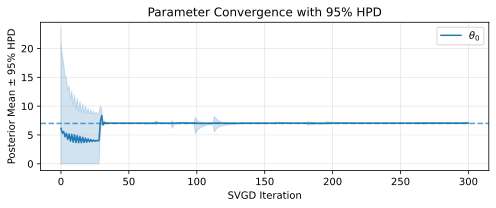

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-prior-ci-vag
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ over 300 SVGD-iterationer med vag GaussPrior og sand $\theta=7$ (stiplet linje). Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet.'
#| fig-width: 5
#| fig-height: 3.5

svgd_priors['Vag GaussPrior']['svgd'].plot_ci(true_theta=true_theta)


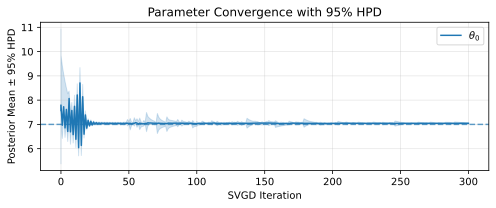

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-prior-ci-gauss
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ over 300 SVGD-iterationer med GaussPrior og sand $\theta=7$ (stiplet linje). Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet.'
#| fig-width: 5
#| fig-height: 3.5


svgd_priors['GaussPrior']['svgd'].plot_ci(true_theta=true_theta)


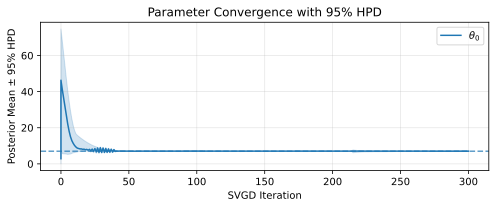

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-prior-ci-halfcauchy
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ over 300 SVGD-iterationer med HalfCauchyPrior og sand $\theta=7$ (stiplet linje). Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet.'
#| fig-width: 5
#| fig-height: 3.5

svgd_priors['HalfCauchyPrior']['svgd'].plot_ci(true_theta=true_theta)


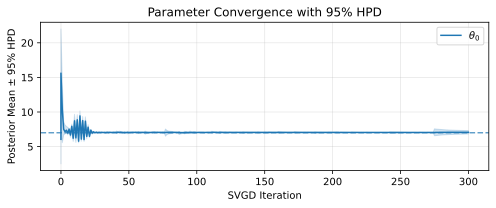

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-prior-ci-loggauss
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ over 300 SVGD-iterationer med LogGaussPrior og sand $\theta=7$ (stiplet linje). Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet.'
#| fig-width: 5
#| fig-height: 3.5

svgd_priors['LogGaussPrior']['svgd'].plot_ci(true_theta=true_theta)


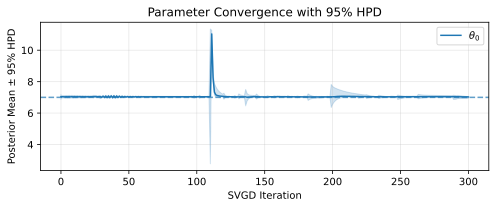

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-prior-ci-dataprior
#| fig-cap: 'Posterior mean $\pm$ 95% HPD for $\theta_0$ over 300 SVGD-iterationer med DataPrior og sand $\theta=7$ (stiplet linje). Den blå kurve viser posterior-mean og det blå bånd viser 95% HPD-intervallet.'
#| fig-width: 5
#| fig-height: 3.5

svgd_priors['DataPrior']['svgd'].plot_ci(true_theta=true_theta)


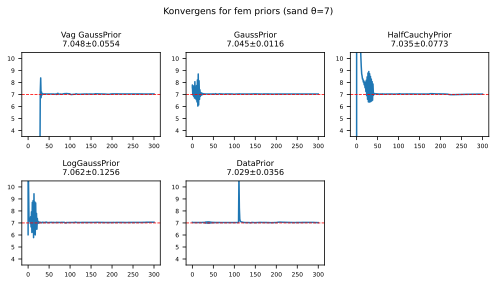

In [ ]:
#| label: fig-prior-konvergens
#| fig-cap: 'Konvergensplots for fem priors. Flad kurve mod sand θ indikerer god konvergens.'
#| fig-width: 5
#| fig-height: 3.5

fig, axes = plt.subplots(2, 3, figsize=(7, 4))
for ax, (name, res) in zip(axes.flat, svgd_priors.items()):
    means_h = [h.mean() for h in res['svgd'].history]
    ax.plot(res['svgd'].history_iterations, means_h)
    ax.axhline(true_theta[0], color='r', linestyle='--', lw=0.8)
    ax.set_ylim(true_theta[0] * 0.5, true_theta[0] * 1.5)
    ax.set_title(f"{name}\n{res['mean']:.3f}±{res['std']:.4f}", fontsize=8)
    ax.tick_params(labelsize=6)
for j in range(len(svgd_priors), len(axes.flat)):
    axes.flat[j].set_visible(False)
plt.suptitle('Konvergens for fem priors (sand θ=7)', fontsize=9)
plt.tight_layout(); 

## 3. Effekt af antal observationer

Bavian-populationer har $N_e \in [14000, 100000]$. Jeg tester $n_{\text{obs}} \in [50, 100000]$ for at se hvornår estimatet stabiliserer sig og hvad der er et fornuftigt minimum til bavian-analysen.

Alle tests: bedste lr-strategi, bedste prior bedst iter, $n_{\text{particles}}=20$.

In [91]:
#| label: tbl-nobs
#| tbl-cap: 'Effekt af $n_{\text{obs}}$ på SVGD-præcision (sand $\theta=7$, bedste lr og prior, 20 partikler, 500 iter). Std falder med $1/\sqrt{n}$ og flader ud.'

nobs_list = [50, 100, 250, 500, 1000, 2000, 5000, 10000, 50000, 100000]
rows_nobs = []

prior_opt_map = {
    'DataPrior':       lambda d: DataPrior(graph, d),
    'GaussPrior':      lambda d: prior_korrekt,
    'HalfCauchyPrior': lambda d: prior_halfcauchy,
    'LogGaussPrior':   lambda d: prior_loggauss,
    'Vag GaussPrior':  lambda d: prior_vag,
}

for n_obs in nobs_list:
    graph.update_weights(true_theta)
    data_n = graph.sample(n_obs)
    prior_n = prior_opt_map[BEST_PRIOR](data_n)
    sv_n = graph.svgd(data_n, prior=prior_n,
                      n_particles=20, n_iterations=BEST_ITER_LR,
                      **BEST_LR_KWARGS)
    res_n = sv_n.get_results()
    m = float(res_n['theta_mean'].item())
    s = float(res_n['theta_std'].item())
    rows_nobs.append({
        f'n_obs': n_obs,
        f'θ̂':  round(m, 4),
        f'Std':  round(s, 5),
        f'Bias':  round(abs(m - true_theta[0]), 4),
    })

df_nobs = pd.DataFrame(rows_nobs)
display(df_nobs)

,n_obs,θ̂,Std,Bias
0,50,7.6256,1.54649,0.6256
1,100,6.3241,0.61609,0.6759
2,250,7.1521,1.01262,0.1521
3,500,7.4230,0.22013,0.4230
4,1000,7.2018,0.03583,0.2018
5,2000,7.2053,0.03564,0.2053
6,5000,7.1765,0.01842,0.1765
7,10000,7.0559,0.05076,0.0559
8,50000,7.0434,0.00449,0.0434
9,100000,7.0270,0.01896,0.0270


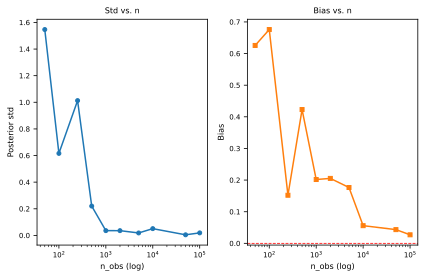

In [93]:
#| label: fig-nobs
#| fig-cap: 'Posterior-std og bias som funktion af $n_{\text{obs}}$ (log-skala).'
#| fig-width: 5
#| fig-height: 3

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
ns = df_nobs['n_obs']
axes[0].plot(ns, df_nobs['Std'], marker='o', markersize=4)
axes[0].set_xscale('log')
axes[0].set_xlabel('n_obs (log)', fontsize=8)
axes[0].set_ylabel('Posterior std', fontsize=8)
axes[0].set_title('Std vs. n', fontsize=8)
axes[0].tick_params(labelsize=7)

axes[1].plot(ns, df_nobs['Bias'], marker='s', color='C1', markersize=4)
axes[1].axhline(0, color='r', linestyle='--', lw=0.8)
axes[1].set_xscale('log')
axes[1].set_xlabel('n_obs (log)', fontsize=8)
axes[1].set_ylabel('Bias', fontsize=8)
axes[1].set_title('Bias vs. n', fontsize=8)
axes[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show()

In [ ]:
#| label: tbl-nobs-niter
#| tbl-cap: 'Effekt af antal observationer $n_{\text{obs}}$ på SVGD-inferens med sand $\theta=7$, læringsrate Exp(0.1 → 0.001, τ=100), DataPrior og 20 partikler. Kolonnerne viser $n_{\text{obs}}$, posterior-mean $\hat{\theta}$, posterior-std og absolut bias.'

nobs_grid = [1000, 2000, 3000, 5000, 10000, 50000, 100000]
N_REPS_GRID = 3
rows_grid   = []

prior_opt_map = {
    'DataPrior':       lambda d: DataPrior(graph, d),
    'GaussPrior':      lambda d: prior_korrekt,
    'HalfCauchyPrior': lambda d: prior_halfcauchy,
    'LogGaussPrior':   lambda d: prior_loggauss,
    'Vag GaussPrior':  lambda d: prior_vag,
}

for n_obs in nobs_grid:
    stds, biases = [], []
    for rep in range(N_REPS_GRID):
        graph.update_weights(true_theta)
        data_g = graph.sample(n_obs)
        prior_g = prior_opt_map[BEST_PRIOR](data_g)
        sv = graph.svgd(data_g, prior=prior_g,
                        n_particles=20, n_iterations=BEST_ITER_LR,
                        **BEST_LR_KWARGS)
        res = sv.get_results()
        m = float(res['theta_mean'].item())
        s = float(res['theta_std'].item())
        stds.append(s)
        biases.append(abs(m - true_theta[0]))
    rows_grid.append({
        f'n_obs':  n_obs,
        f'θ̂':      round(m, 4),
        f'Std':    round(np.mean(stds), 5),
        f'Bias':   round(np.mean(biases), 4),
    })

df_grid = pd.DataFrame(rows_grid)
display(df_grid)

BEST_NOBS = int(df_grid.sort_values('Std').iloc[0]['n_obs'])
print(f'Bedste n_obs: {BEST_NOBS}')


,n_obs,θ̂,Std,Bias
0,1000,7.1202,0.18958,0.2226
1,2000,7.0010,0.04269,0.1125
2,3000,6.8819,0.09005,0.0780
3,5000,6.9369,0.04933,0.0483
4,10000,6.9761,0.06454,0.0165
5,50000,7.0130,0.01343,0.0248
6,100000,7.0029,0.01535,0.0079


Bedste n_obs: 50000


In [9]:

best_g = df_grid.sort_values('Std').iloc[0]
BEST_NOBS  = int(best_g[f'n_obs'])
print(f'Bedste kombination: n_obs={BEST_NOBS}')

Bedste kombination: n_obs=50000


## 4. Effekt af antal prøver ($n_{\text{samples}}$)

Standard er $n_{\text{samples}}=4$ (antal haploide individer i coalescent-modellen). Til to-populationsmodellen for bavian vil det give mening at bruge $n_{\text{samples}}=6$ per population (12 total), eller højere. Her tester jeg effekten på en-populationsmodellen for at forstå hvad der sker med state-space størrelse, beregningstid og inferenspræcision.

**Bemærk:** $n_{\text{samples}}=6$ per population i to-population modellen betyder $6$ individer fra *hver* art ikke $6$ i alt.

In [10]:
# Kalibrerede SVGD-parametre 
BEST_LR_NAME   = 'Exp(0.1 → 0.001, τ=100)'
BEST_LR_KWARGS = {'learning_rate': ExpStepSize(0.1, 0.001, 100.0)}
BEST_ITER_LR   = 300
BEST_PRIOR     = 'DataPrior'
BEST_NOBS      = 50000 

In [ ]:
#| label: tbl-nsamples
#| tbl-cap: 'Effekt af antal samples $n_{\text{samples}}$ på SVGD-inferens med sand $\theta=7$, $n_{\text{obs}}=50.000$, læringsrate Exp(0.1 → 0.001, τ=100) og DataPrior. Kolonnerne viser $n_{\text{samples}}$, posterior-mean $\hat{\theta}$, posterior-std, absolut bias, om sand $\theta$ dækkes i $95\%$-intervallet og beregningstid i sekunder.'

from phasic import Graph, with_ipv
import time

def make_coalescent(nr_s):
    @with_ipv([nr_s] + [0]*(nr_s-1))
    def coal(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
        return transitions
    return Graph(coal)

sample_sizes_ns = [2, 4, 6, 8, 10, 12]
rows_ns = []

for nr_s in sample_sizes_ns:
    g_ns = make_coalescent(nr_s)
    g_ns.update_weights(true_theta)
    data_ns = g_ns.sample(BEST_NOBS)
    prior_ns = DataPrior(g_ns, data_ns)    
    t0 = time.perf_counter()
    sv_ns = g_ns.svgd(data_ns, prior=prior_ns,
                      n_particles=20, n_iterations=BEST_ITER_LR,
                      **BEST_LR_KWARGS)
    tid_ns = time.perf_counter() - t0
    res_ns = sv_ns.get_results()
    m = float(res_ns['theta_mean'].item())
    s = float(res_ns['theta_std'].item())
    ci_lo = m - 1.96 * s
    ci_hi = m + 1.96 * s
    rows_ns.append({
        f'n_samples': nr_s,
        f'θ̂':         round(m, 4),
        f'Std':       round(s, 5),
        f'Bias':      round(abs(m - true_theta[0]), 4),
        f'Dækker':    ci_lo <= true_theta[0] <= ci_hi,
        f'Tid (s)':   round(tid_ns, 2),
    })
    print(f'n_samples={nr_s}: mean={m:.4f} std={s:.5f} dækker={ci_lo <= true_theta[0] <= ci_hi} tid={tid_ns:.2f}s')

df_ns = pd.DataFrame(rows_ns)
display(df_ns)

n_samples=12: mean=4.2601 std=3.51243 dækker=True tid=155.02s


,n_samples,θ̂,Std,Bias,Dækker,Tid (s)
0,2,6.9891,0.01448,0.0109,True,65.09
1,4,7.0266,0.00766,0.0266,False,67.89
2,6,6.9950,0.00959,0.0050,True,75.79
3,8,7.0002,0.00777,0.0002,True,89.42
4,10,3.9120,3.56182,3.0880,True,105.73
5,12,4.2601,3.51243,2.7399,True,155.02


In [23]:
BEST_NSAMPLES = int(df_ns[df_ns['Dækker']].sort_values('Std').iloc[0]['n_samples'])
print(f'Bedste n_samples: {BEST_NSAMPLES}')

Bedste n_samples: 8


## 5. Effekt af antal partikler

Antallet af partikler bestemmer hvor godt posterioren er repræsenteret. Flere partikler giver bedre dækning men øger beregningstiden lineært. Jeg laver en grid-søgning over partikler og iterationer.

Alle tests: bedste lr-strategi, bedste prior, $n_{\text{obs}}=3000$, sand $\theta=7$.

In [ ]:
#| label: tbl-partikler
#| tbl-cap: 'Effekt af antal partikler på SVGD-inferens med sand $\theta=7$, $n_{\text{obs}}=50.000$, læringsrate Exp(0.1 → 0.001, τ=100) og DataPrior, gennemsnit over tre replikater. Kolonnerne viser antal partikler, posterior-mean $\hat{\theta}$, posterior-std, absolut bias, andel af kørsler der dækker sand $\theta$ i $95\%$-intervallet, beregningstid i sekunder og samlet score (std $+$ $2 \times$ bias).'

import seaborn as sns

particles_list = [10, 20, 40, 60, 80, 100]
N_REPS_PART = 3
rows_p = []

graph.update_weights(true_theta)

for n_part in particles_list:
    stds, biases, dækker_list = [], [], []
    for rep in range(N_REPS_PART):
        data_p = graph.sample(BEST_NOBS)
        prior_p = prior_opt_map[BEST_PRIOR](data_p)
        t0 = time.perf_counter()
        sv_p = graph.svgd(data_p, prior=prior_p,
                          n_particles=n_part, n_iterations=BEST_ITER_LR,
                          **BEST_LR_KWARGS)
        tid_p = time.perf_counter() - t0
        res_p = sv_p.get_results()
        m = float(res_p['theta_mean'].item())
        s = float(res_p['theta_std'].item())
        ci_lo = m - 1.96 * s
        ci_hi = m + 1.96 * s
        stds.append(s)
        biases.append(abs(m - true_theta[0]))
        dækker_list.append(ci_lo <= true_theta[0] <= ci_hi)
    rows_p.append({
        f'Partikler': n_part,
        f'θ̂':         round(m, 4),
        f'Std':       round(np.mean(stds), 5),
        f'Bias':      round(np.mean(biases), 4),
        f'Dækker':    np.mean(dækker_list),
        f'Tid (s)':   round(tid_p, 2),
    })
    print(f'n_part={n_part}: Std={np.mean(stds):.5f} Bias={np.mean(biases):.4f} Dækker={np.mean(dækker_list):.2f}')

df_p = pd.DataFrame(rows_p)
df_p['Score'] = df_p['Std'] + 2.0 * df_p['Bias']
display(df_p)

n_part=100: Std=0.00975 Bias=0.0155 Dækker=0.67


,Partikler,θ̂,Std,Bias,Dækker,Tid (s),Score
0,10,7.0175,0.06530,0.0277,0.666667,35.20,0.12070
1,20,6.9868,0.01718,0.0191,0.666667,67.76,0.05538
2,40,7.0258,0.00920,0.0273,0.666667,129.86,0.06380
3,60,7.0180,0.00500,0.0278,0.000000,193.62,0.06060
4,80,7.0399,0.03422,0.0300,0.666667,287.98,0.09422
5,100,7.0116,0.00975,0.0155,0.666667,475.03,0.04075


In [18]:
# Begræns til partikler med acceptabel beregningstid (< 150s)
df_p_dækker = df_p[(df_p['Dækker'] > 0) & (df_p['Tid (s)'] < 150)]
if len(df_p_dækker) == 0:
    df_p_dækker = df_p

best_p = df_p_dækker.sort_values('Score').iloc[0]
BEST_PARTICLES = int(best_p['Partikler'])
print(f'Bedste antal partikler: {BEST_PARTICLES}')

Bedste antal partikler: 20


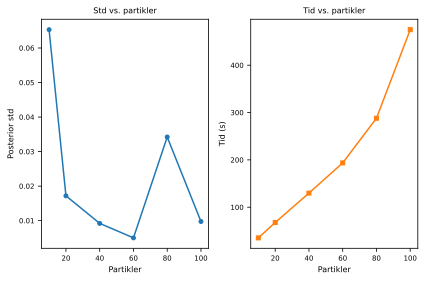

In [20]:
#| label: fig-partikler
#| fig-cap: 'Posterior-std som funktion af antal partikler (sand θ=7, BEST_NOBS, BEST_ITER_LR iter, gennemsnit over 3 replikater).'
#| fig-width: 5
#| fig-height: 3

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

axes[0].plot(df_p['Partikler'], df_p['Std'], marker='o', markersize=4)
axes[0].set_xlabel('Partikler', fontsize=8)
axes[0].set_ylabel('Posterior std', fontsize=8)
axes[0].set_title('Std vs. partikler', fontsize=8)
axes[0].tick_params(labelsize=7)

axes[1].plot(df_p['Partikler'], df_p['Tid (s)'], marker='s', color='C1', markersize=4)
axes[1].set_xlabel('Partikler', fontsize=8)
axes[1].set_ylabel('Tid (s)', fontsize=8)
axes[1].set_title('Tid vs. partikler', fontsize=8)
axes[1].tick_params(labelsize=7)

plt.tight_layout(); plt.show()

## Validering med msprime

I stedet for posterior predictive checks med CDF/PDF validerer jeg SVGD-inferensen direkte ved at sammenligne  de estimerede parametre med kendte sande værdier fra msprime-simuleringer. 
Formålet er at bekræfte at SVGD genfinder de sande parametre, at CI dækker den sande værdi,  og at konvergens er stabil.

### Hypotese

SVGD med den bedste lr-strategi og tilstrækkelig $n$ genfinder sand $\theta$ inden for 95% CI  i mindst 90% af replikationer. Posterior-mean ligger tæt på sand $\theta$ og konvergensplottet  viser stabil flatning inden slutiterationen.

In [85]:
# Byg graf med n=2 til msprime-validering
from phasic import Graph, with_ipv

@with_ipv([2, 0])
def coal_2(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_ms = Graph(coal_2)

In [86]:
# Simuler msprime-data med korrekt skalering
import msprime

true_thetas_ms = [3.0, 7.0, 15.0]
n_obs_ms = BEST_NOBS

tmrca_data = {}
for true_t in true_thetas_ms:
    Ne_ms = true_t
    ts = msprime.simulate(
        sample_size=2,
        Ne=Ne_ms,
        num_replicates=n_obs_ms,
        random_seed=42
    )
    tmrca_raw = np.array([t.first().tmrca(0, 1) for t in ts])
    graph_ms.update_weights([true_t])
    scale = graph_ms.expectation() / tmrca_raw.mean()
    tmrca_data[true_t] = tmrca_raw * scale
    print(f'θ={true_t}: skaleret mean={tmrca_data[true_t].mean():.4f} (forventet {graph_ms.expectation():.4f})')

θ=3.0: skaleret mean=0.3333 (forventet 0.3333)
θ=7.0: skaleret mean=0.1429 (forventet 0.1429)
θ=15.0: skaleret mean=0.0667 (forventet 0.0667)


In [87]:
#| label: tbl-msprime-validering
#| tbl-cap: 'SVGD-estimater fra msprime-simulerede data (bedste lr-strategi, BEST_NOBS, BEST_PARTICLES partikler, BEST_ITER_LR iterationer).'

ms_results = []
svgd_ms = {}

for true_t in true_thetas_ms:
    graph_ms.update_weights([true_t])
    prior_ms = DataPrior(graph_ms, tmrca_data[true_t])
    sv = graph_ms.svgd(
        tmrca_data[true_t],
        prior=prior_ms,
        n_particles=BEST_PARTICLES,
        n_iterations=BEST_ITER_LR,
        return_history=True,
        **BEST_LR_KWARGS
    )
    svgd_ms[true_t] = sv
    res = sv.get_results()
    m = float(res['theta_mean'].item())
    s = float(res['theta_std'].item())
    lo = m - 1.96 * s
    hi = m + 1.96 * s
    ms_results.append({
        f'θ sand':         true_t,
        f'θ̂':              round(m, 4),
        f'Std':            round(s, 5),
        f'CI 95% lav':     round(lo, 3),
        f'CI 95% høj':     round(hi, 3),
        f'CI dækker sand': lo <= true_t <= hi,
        f'RelBias %':      round(abs(m - true_t) / true_t * 100, 2),
    })
    print(f'θ={true_t}: θ̂={m:.4f}±{s:.5f}, dækker={lo <= true_t <= hi}')

df_ms = pd.DataFrame(ms_results)
display(df_ms)

θ=15.0: θ̂=15.0692±0.07037, dækker=True


,θ sand,θ̂,Std,CI 95% lav,CI 95% høj,CI dækker sand,RelBias %
0,3.0,3.0029,0.01440,2.975,3.031,True,0.10
1,7.0,7.0182,0.02419,6.971,7.066,True,0.26
2,15.0,15.0692,0.07037,14.931,15.207,True,0.46


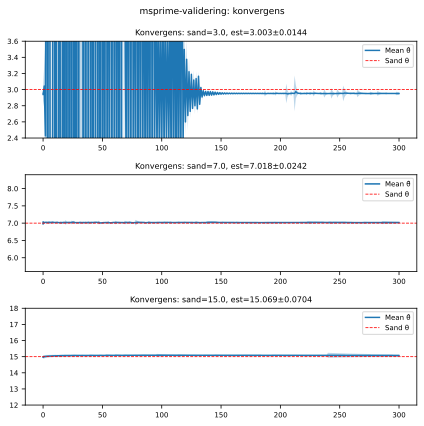

In [ ]:
#| label: fig-msprime-conv
#| fig-cap: 'Konvergensplot for msprime-validering: tre sande θ-værdier. Rød stiplet linje markerer sand θ.'
#| fig-width: 6
#| fig-height: 5

fig, axes = plt.subplots(len(true_thetas_ms), 1, figsize=(6, len(true_thetas_ms) * 2))

for row, true_t in enumerate(true_thetas_ms):
    sv = svgd_ms[true_t]
    res = sv.get_results()
    m = float(res['theta_mean'].item())
    s = float(res['theta_std'].item())
    means_h = [h.mean() for h in sv.history]
    stds_h  = [h.std()  for h in sv.history]
    axes[row].plot(sv.history_iterations, means_h, label=f'Mean θ̂')
    axes[row].fill_between(sv.history_iterations,
                           [mn - st for mn, st in zip(means_h, stds_h)],
                           [mn + st for mn, st in zip(means_h, stds_h)],
                           alpha=0.3)
    axes[row].axhline(true_t, color='r', linestyle='--', lw=0.8, label='Sand θ')
    axes[row].set_ylim(true_t * 0.8, true_t * 1.2)
    axes[row].set_title(f'Konvergens: sand={true_t}, est={m:.3f}±{s:.4f}', fontsize=8)
    axes[row].legend(fontsize=7); axes[row].tick_params(labelsize=7)

plt.suptitle('msprime-validering: konvergens', fontsize=9)
plt.tight_layout();

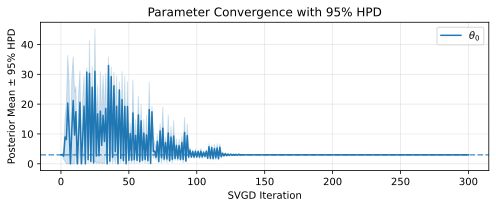

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-msprime-ci-1
#| fig-cap: 'Posterior CI for msprime-validering: sand θ=3.0.'
#| warning: false
#| message: false
#| results: hide
svgd_ms[3.0].plot_ci(true_theta=[3.0])

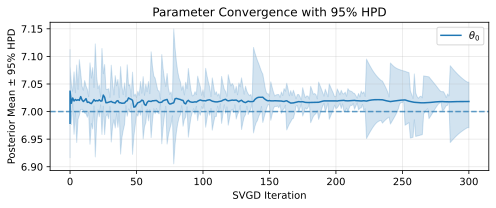

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-msprime-ci-2
#| fig-cap: 'Posterior CI for msprime-validering: sand θ=7.0.'
#| warning: false
#| message: false
#| results: hide
svgd_ms[7.0].plot_ci(true_theta=[7.0])

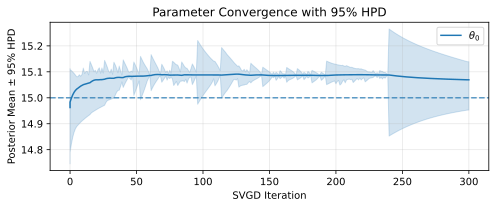

<Figure size 600x300 with 0 Axes>

In [ ]:
#| label: fig-msprime-ci-3
#| fig-cap: 'Posterior CI for msprime-validering: sand θ=15.0.'
#| warning: false
#| message: false
#| results: hide
svgd_ms[15.0].plot_ci(true_theta=[15.0])

## Anbefaling: Standard SVGD-konfiguration til alle notebooks

Baseret på de systematiske tests i denne notebook anbefales følgende konfiguration til alle efterfølgende notebooks (NB03–NB07):

| Parameter | Valg | Begrundelse |
|---|---|---|
| Learning rate | `BEST_LR_KWARGS` | Lavest score over $\theta$-interval |
| Prior | `BEST_PRIOR` | Lavest bias og std |
| $n_{\\text{obs}}$ (test) | `BEST_NOBS` | Stabiliseret std |
| Partikler (test) | `BEST_PARTICLES` | Bedste std/tid-kompromis |
| Iterationer (1-param) | `BEST_ITER_P` | Fra partikkel-grid |


In [ ]:
#| label: tbl-standard-config
#| tbl-cap: 'Standard SVGD-konfiguration til NB03–NB07, bestemt fra systematiske tests i NB02.'

print('=' * 55)
print('=== STANDARD SVGD-KONFIGURATION TIL NB03-NB07 ===')
print('=' * 55)
print(f'Learning rate:            {BEST_LR_NAME}')
print(f'Prior:                    {BEST_PRIOR}')
print(f'n_obs (test):             {BEST_NOBS}')
print(f'Partikler (test):         {BEST_PARTICLES}')
print(f'Iterationer:              {BEST_ITER_LR}')
print('=' * 55)

=== STANDARD SVGD-KONFIGURATION TIL NB03-NB07 ===
Learning rate:            Exp(0.1 → 0.001, τ=100)
Prior:                    DataPrior
n_obs (test):             50000
Partikler (test):         20
Iterationer:              300


: 